In [1]:
# %pip install scipy
# %pip install tensorflow

In [2]:
#Imports

import pandas as pd
import seaborn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

#tensorflow imports for transformer model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import TextVectorization, Embedding, Dense
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from tensorflow.keras.layers import GlobalAveragePooling1D, Dropout
from tensorflow.keras import layers, Model, Input


In [3]:
#Data Parsing

#Open and read the dataset file
with open("dataset_", "r") as f:
    lines = f.readlines()

#Skip to where the data actually starts in the file
data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

#From here parse the dataset into a usable dataset
dataset = pd.read_csv("dataset_", skiprows=data_start+1, header=None)

#Get the feature column
dataset.columns = ['id','rated','created_at','last_move_at','turns','victory_status','winner','increment_code','white_id','white_rating','black_id','black_rating','moves','opening_eco','opening_name','opening_ply']

#Look at the dataset before preprocessing
dataset.head()



,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,a-00,1191,'d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba...,D10,'Slav Defense: Exchange Variation',5
1,l1NXvwaE,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,skinnerua,1261,'d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc...,B00,'Nimzowitsch Defense: Kennedy Variation',4
2,mIICvQHh,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,a-00,1500,'e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 N...,C20,'King\'s Pawn Game: Leonardis Variation',3
3,kWKvrqYL,True,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,'d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 ...,D02,'Queen\'s Pawn Game: Zukertort Variation',3
4,9tXo1AUZ,True,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,adivanov2009,1469,'e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 ...,C41,'Philidor Defense',5


In [4]:
#Data Preprocessing

# Additional Feature Extraction, Some additional features can be extracted to provide relevent data

#rating_diff: the difference in rating between players
#base_time: the base time amount set for the game
#time_increment: the time gained per move
#opening_strategy: Strategy of opening correlating to eco code letter (A, B, C, D, E)

dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"] 
dataset[["base_time", "time_increment"]] = dataset["increment_code"].str.split("+", expand=True) 
dataset["opening_strategy"] = dataset["opening_eco"].str[0] 


#Feature Refinement (Convert features to values that can be used in analysis)

#Convert boolean to integers
dataset["rated"] = dataset["rated"].astype(str).str.lower().map({"true": 1, "false": 0})

#Convert time to integers
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

#Get unique values of opening code and victory type
opening_strategy_values = dataset["opening_strategy"].unique()

winner_values = dataset["winner"].unique()
victory_status_values = dataset["victory_status"].unique()


#Data encoding (Encode non-numeric feature data into representative values that can be used for anlaysis)

#Create encoder to convert string data to binary array data
encoder = OneHotEncoder(categories=[opening_strategy_values, winner_values, victory_status_values], handle_unknown="ignore", sparse_output=False)

#Encode the data to unique values
encoded_Data = encoder.fit_transform(dataset[["opening_strategy", "winner", "victory_status"]])

#Create a dataframe from the encoded data to be appended to the dataset
encoded_dataframe = pd.DataFrame(encoded_Data, columns=encoder.get_feature_names_out(["opening_strategy", "winner", "victory_status"]), index = dataset.index)

#Append the encoded data to the dataset
dataset = pd.concat([dataset, encoded_dataframe], axis=1)



dataset.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,rating_diff,base_time,time_increment,opening_strategy,opening_strategy_D,opening_strategy_B,opening_strategy_C,opening_strategy_A,opening_strategy_E,winner_white,winner_black,winner_draw,victory_status_outoftime,victory_status_resign,victory_status_mate,victory_status_draw
0,TZJHLljE,0,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,a-00,1191,'d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba...,D10,'Slav Defense: Exchange Variation',5,309,15,2,D,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,l1NXvwaE,1,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,skinnerua,1261,'d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc...,B00,'Nimzowitsch Defense: Kennedy Variation',4,61,5,10,B,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,mIICvQHh,1,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,a-00,1500,'e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 N...,C20,'King\'s Pawn Game: Leonardis Variation',3,-4,5,10,C,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,kWKvrqYL,1,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,'d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 ...,D02,'Queen\'s Pawn Game: Zukertort Variation',3,-15,20,0,D,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9tXo1AUZ,1,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,adivanov2009,1469,'e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 ...,C41,'Philidor Defense',5,54,30,3,C,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


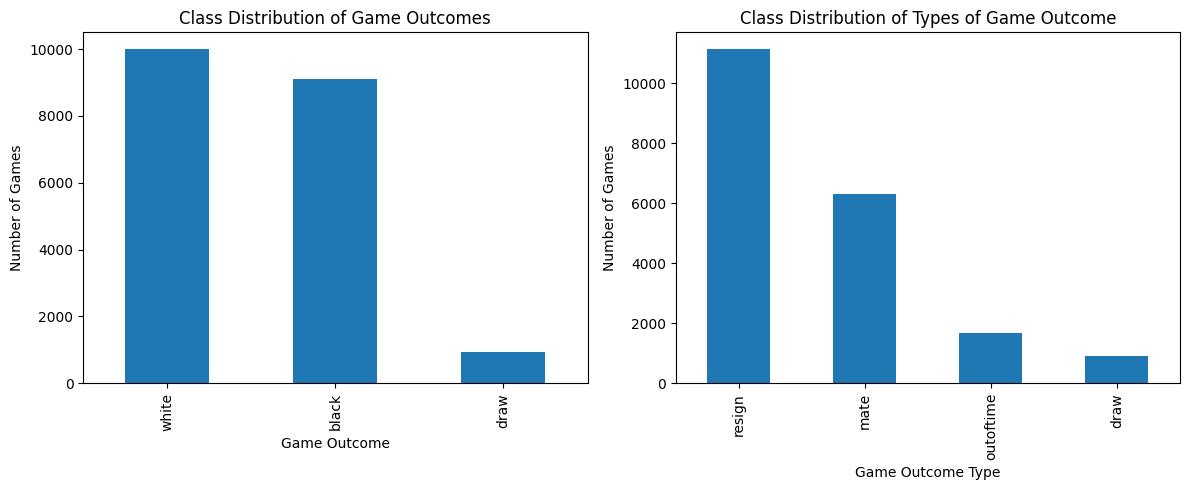

In [5]:
# get the number of each game outcome
winner_class_counts = dataset["winner"].value_counts()

# get the number of each victory type
type_winner_class_counts = dataset["victory_status"].value_counts()

# create two plots in one figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# plot winner distribution
winner_class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Game Outcome")
axes[0].set_ylabel("Number of Games")

# plot victory type distribution
type_winner_class_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Types of Game Outcome")
axes[1].set_xlabel("Game Outcome Type")
axes[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.show()

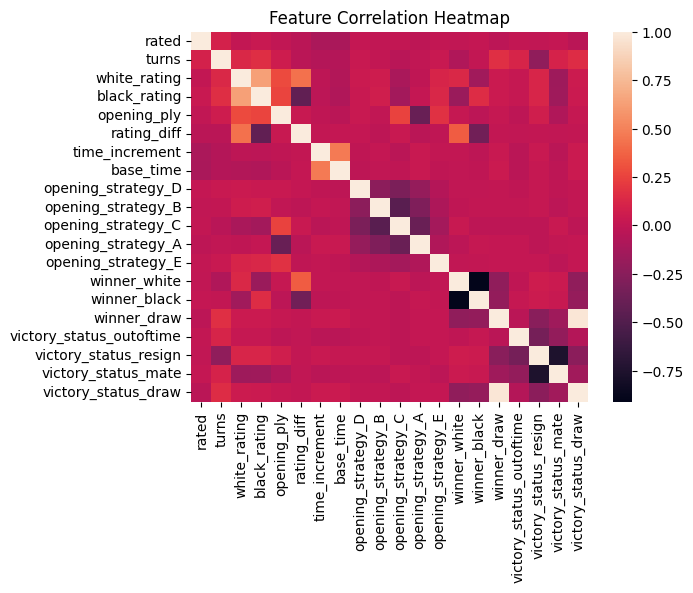

In [6]:
#use only the numeric features
numeric_features = dataset[["rated", "turns", "white_rating", "black_rating", "opening_ply", "rating_diff", "time_increment", "base_time"] + list(encoded_dataframe.columns)]

#Create a correlation matrix
corr_matrix = numeric_features.corr()

# Plot feature heatmap
plt.figure()
seaborn.heatmap(corr_matrix)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:

#Create training data for Random Forest Model
rf_dataset = dataset.copy()

#Add desired features to be used
features = ["rated", "turns", "white_rating", "black_rating", "opening_ply", "rating_diff", "base_time", "time_increment"]

#Add encoded opening strategy
opening_cols = [col for col in rf_dataset.columns if "opening_strategy_" in col]

#Create the total features to be used
x = rf_dataset[features + opening_cols]

#Define what we are trying to predict
y_winner = rf_dataset["winner"]
y_status = rf_dataset["victory_status"]

#Create the training and testing data
x_train, x_test, y_winner_train, y_winner_test, y_status_train, y_status_test = train_test_split( x, y_winner, y_status, 
    test_size=0.2, random_state=42, stratify=y_winner)



In [8]:


#Define estimators number here to allow for easy manipulation if necesary
rf_estimators = 250

#Define Random Forest Classifier for determineing the Winner and the Victory Status
rf_winner = RandomForestClassifier(n_estimators=rf_estimators, random_state=42, class_weight="balanced")
rf_status = RandomForestClassifier(n_estimators=rf_estimators, random_state=42, class_weight="balanced")


#5-Crossfold Validation

# Winner model CV
winner_f1_scores = cross_val_score(rf_winner, x_train, y_winner_train, cv=5, scoring="f1_weighted")

# Victory status model CV
status_f1_scores = cross_val_score(rf_status, x_train, y_status_train, cv=5, scoring="f1_weighted")

print("Winner weighted F1 scores:", winner_f1_scores)
print("Winner Mean weighted F1:", winner_f1_scores.mean())

print("\nStatus weighted F1 scores:", status_f1_scores)
print("Status Mean weighted F1:", status_f1_scores.mean())


#Train models
rf_winner.fit(x_train, y_winner_train)
rf_status.fit(x_train, y_status_train)


#test models
y_winner_pred = rf_winner.predict(x_test)
y_status_pred = rf_status.predict(x_test)



# Winner metrics
winner_accuracy = accuracy_score(y_winner_test, y_winner_pred)
winner_precision = precision_score(y_winner_test, y_winner_pred, average="weighted")
winner_recall = recall_score(y_winner_test, y_winner_pred, average="weighted")

# Status metrics
status_accuracy = accuracy_score(y_status_test, y_status_pred)
status_precision = precision_score(y_status_test, y_status_pred, average="weighted")
status_recall = recall_score(y_status_test, y_status_pred, average="weighted")


#Model Performance

print("\nWinner Model")
print("Accuracy:", winner_accuracy)
print("Precision (weighted):", winner_precision)
print("Recall (weighted):", winner_recall)

print("\nVictory Status Model")
print("Accuracy:", status_accuracy)
print("Precision (weighted):", status_precision)
print("Recall (weighted):", status_recall)

Winner weighted F1 scores: [0.63011313 0.63607355 0.62916773 0.62851202 0.62212882]
Winner Mean weighted F1: 0.6291990501840058

Status weighted F1 scores: [0.55532963 0.5617043  0.55824229 0.5470285  0.54359804]
Status Mean weighted F1: 0.5531805517017366

Winner Model
Accuracy: 0.6505483549351944
Precision (weighted): 0.6521446749460315
Recall (weighted): 0.6505483549351944

Victory Status Model
Accuracy: 0.6021934197407777
Precision (weighted): 0.596264813494583
Recall (weighted): 0.6021934197407777


In [9]:
#Copy dataset for transformer model
transformer_dataset = dataset.copy()

#Clean moves for transformer analysis
cleaned_moves = []

#

# Iterate through all the moves strings
for move_string in transformer_dataset["moves"]:

    #Get the string, unnencassry whitespace and ' fund at begging and end
    move_string = str(move_string).strip().strip("'")
        
    # If last character is '#', remove last move
    if move_string[-1] == "#":
        last_space = move_string.rfind(" ")
        move_string = move_string[:last_space]
    
    cleaned_moves.append(move_string)

# Add cleaned column
transformer_dataset["moves_clean"] = cleaned_moves

#There are ~28000 possible chess notations barring checkmates leading to 30000 max tokens for safety
max_tokens = 30000

#The max moves is 349, 350 for safety
sequence_length = 350

vectorizer = TextVectorization(max_tokens=max_tokens, output_mode="int", output_sequence_length=sequence_length,
    standardize=None, split="whitespace")

# Adapt on cleaned moves
move_text = transformer_dataset["moves_clean"].astype(str).values
vectorizer.adapt(move_text)

# Convert to vectors
move_vectors = vectorizer(move_text).numpy()

# Check vector shape
print("\nVector shape:", move_vectors.shape)

#Look at first cleaned moves
print("\nFirst cleaned move string:")
print(transformer_dataset.loc[0, "moves_clean"])

#Look at first token vector
print("\nFirst token vector:")
print(move_vectors[0])

#Look at first 30 tokens
print("\nFirst 30 vocabulary tokens:")
print(vectorizer.get_vocabulary()[:30])

#Check unknown index value, should be 0
unk_index = 1
num_unk = np.sum(move_vectors == unk_index)
print("Total [UNK] tokens in all vectors:", num_unk)

#Create winner and victory status encoder
winner_encoder = LabelEncoder()
status_encoder = LabelEncoder()

#encoder winner and victory status
y_winner = winner_encoder.fit_transform(dataset["winner"])
y_status = status_encoder.fit_transform(dataset["victory_status"])



Vector shape: (20058, 350)

First cleaned move string:
d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5 Bf4

First token vector:
[  6   9  12  24  69  13 472 218   3 225  10 344  57   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

In [10]:
# Transformer Embedding

#   1. Re-builds the vectorizer with the actual vocabulary size.
#   2. Adding a proper token + positional Embedding layer.
#   3. Defining a minimal Transformer encoder block.
#   4. Building two classification heads (winner / victory_status).
#   5. Training and evaluating both models.

sequence_length = 350

_tmp = TextVectorization(max_tokens=None, output_mode='int',
                         output_sequence_length=sequence_length,
                         standardize=None, split='whitespace')
_tmp.adapt(move_text)
true_vocab_size = len(_tmp.get_vocabulary())
print(f"True vocabulary size: {true_vocab_size}")

vectorizer = TextVectorization(max_tokens=true_vocab_size, output_mode='int',
                               output_sequence_length=sequence_length,
                               standardize=None, split='whitespace')
vectorizer.adapt(move_text)

move_vectors = vectorizer(move_text).numpy()
print(f"move_vectors shape: {move_vectors.shape}")

vocab_size = len(vectorizer.get_vocabulary())
print(f"Embedding vocab size: {vocab_size}")

winner_encoder = LabelEncoder()
status_encoder  = LabelEncoder()
y_winner = winner_encoder.fit_transform(transformer_dataset['winner'])
y_status = status_encoder.fit_transform(transformer_dataset['victory_status'])
n_winner_classes = len(winner_encoder.classes_)
n_status_classes = len(status_encoder.classes_)
print(f"Winner classes : {list(winner_encoder.classes_)}")
print(f"Status  classes: {list(status_encoder.classes_)}")

X_tr, X_te, yw_tr, yw_te, ys_tr, ys_te = train_test_split(
    move_vectors, y_winner, y_status,
    test_size=0.2, random_state=42, stratify=y_winner
)


class TokenAndPositionEmbedding(layers.Layer):
    """Combines token embedding + learnable positional embedding."""
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim,
                                   mask_zero=True)
        self.pos_emb   = Embedding(input_dim=maxlen,    output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        tok = self.token_emb(x)
        pos = self.pos_emb(positions)
        return tok + pos


class TransformerBlock(layers.Layer):
    """One transformer encoder layer: Multi-Head Attention + FFN."""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att  = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn  = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.ln1  = LayerNormalization(epsilon=1e-6)
        self.ln2  = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

    def call(self, x, training=False):
        attn_out = self.att(x, x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        out1 = self.ln1(x + attn_out)

        ffn_out  = self.ffn(out1)
        ffn_out  = self.drop2(ffn_out, training=training)
        return self.ln2(out1 + ffn_out)


def build_transformer(vocab_size, maxlen, n_classes,
                      embed_dim=64, num_heads=4, ff_dim=128):
    """
    Returns a compiled transformer classifier.
    embed_dim : dimension of token + position embeddings
    num_heads : number of attention heads
    ff_dim    : inner dimension of the feed-forward sublayer
    """
    inputs = Input(shape=(maxlen,))

    x = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)(inputs)

    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)

    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("\n── Training Winner model ──")
tf_winner = build_transformer(vocab_size, sequence_length, n_winner_classes)
tf_winner.summary()

history_w = tf_winner.fit(
    X_tr, yw_tr,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

print("\n── Training Victory Status model ──")
tf_status = build_transformer(vocab_size, sequence_length, n_status_classes)

history_s = tf_status.fit(
    X_tr, ys_tr,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

def evaluate(model, X_te, y_te, encoder, label):
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    print(f"\n── {label} ──")
    print(f"  Accuracy : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_te, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1       : {f1_score(y_te, y_pred, average='weighted', zero_division=0):.4f}")

evaluate(tf_winner, X_te, yw_te, winner_encoder, "Winner Transformer")
evaluate(tf_status, X_te, ys_te, status_encoder, "Victory Status Transformer")

True vocabulary size: 3825
move_vectors shape: (20058, 350)
Embedding vocab size: 3825
Winner classes : ['black', 'draw', 'white']
Status  classes: ['draw', 'mate', 'outoftime', 'resign']

── Training Winner model ──



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 350)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 350, 64)        │       267,200 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 350, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,755 (1.35 MB)

 Trainable params: 354,755 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 344ms/step - accuracy: 0.4885 - loss: 0.8624 - val_accuracy: 0.5146 - val_loss: 0.8143
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 74s 327ms/step - accuracy: 0.4960 - loss: 0.8432 - val_accuracy: 0.5184 - val_loss: 0.8132
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 76s 301ms/step - accuracy: 0.6160 - loss: 0.7771 - val_accuracy: 0.7009 - val_loss: 0.6652
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 72s 320ms/step - accuracy: 0.7165 - loss: 0.6632 - val_accuracy: 0.7202 - val_loss: 0.6316
Epoch 5/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 78s 344ms/step - accuracy: 0.7432 - loss: 0.6127 - val_accuracy: 0.7209 - val_loss: 0.6393
Epoch 6/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 80s 352ms/step - accuracy: 0.7627 - loss: 0.5712 - val_accuracy: 0.7265 - val_loss: 0.6700
Epoch 7/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 79s 352ms/step - accuracy: 0.7792 - loss: 0.5331 - val_accuracy: 0.7146 - val_loss: 0.6839
Epoch 8/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 86s 382ms/step - accuracy: 0.7925 - loss: 0